This notebook runs the reduced-order model (ROM) experiments for the parametric time-domain Maxwell equations.

The full-order model (FOM) is a finite element discretization of Maxwell's equations on a 3D domain, tracking the electric field $\boldsymbol{E}$ and magnetic flux density $\boldsymbol{B}$. The system is driven by a Gaussian current source centered at $(x_0, y_0, z_0) \in [0,2]^3$ with a fixed width, direction, and smooth temporal pulse envelope. The source location is the only parameter, giving $\mu = (x_0, y_0, z_0)$, with 160 training and 40 test samples over $t \in [0, 2.5]$.

Tucker decompositions of the $\boldsymbol{E}$ and $\boldsymbol{B}$ snapshot tensors are computed separately. The reduced bases are **enriched**: the $\boldsymbol{E}$ basis is augmented with the weak curl of the $\boldsymbol{B}$ modes, and the $\boldsymbol{B}$ basis is augmented with the strong curl of the $\boldsymbol{E}$ modes. This curl-enrichment preserves the Gauss law structure of Maxwell's equations in the reduced space.

The parametric current source is hyperreduced using Q-DEIM, which identifies a small set of reduced integration cells so that the current assembly cost is independent of the full mesh size.

Three basis construction methods are compared:
- **Monolithic**: a single global SVD basis computed from all training snapshots
- **Radial Basis Functions (RBF)**: a parameter-interpolated basis using Gaussian RBF weights on the Tucker parameter factor
- **Mamonov/Olshanskii (MO)**: a locally informed basis using MO interpolation weights

ROM errors are reported for both $\boldsymbol{E}$ and $\boldsymbol{B}$ across a sweep of basis sizes.

# Scripts

In [ ]:
# Generate FOM snapshots and save to disk
!python generate_data.py

In [ ]:
# Compute Tucker decompositions of E and B snapshot tensors
!python tucker.py

In [3]:
# Compute Q-DEIM basis and reduced integration cells for current assembly
!python generate_current.py

Saving to: data/Maxwell
Training parameters: 160
Q-DEIM rank: 80
N_E (DOFs): 49320
n_cells: 40500, n_local_dofs: 6
  assembled 1/160
  assembled 20/160
  assembled 40/160
  assembled 60/160
  assembled 80/160
  assembled 100/160
  assembled 120/160
  assembled 140/160
  assembled 160/160
J_snap shape: (49320, 160)
J_snap norm range: [2.4564e-01, 2.4862e-01]

Computing truncated SVD (rank=80)...
Singular values (first 10): [1.97700899 1.17009658 1.1046453  0.99947052 0.66827836 0.6238848
 0.55515147 0.46264809 0.42239025 0.38997221]
Singular values (last 5):   [0.00409726 0.00377631 0.00365149 0.00348753 0.00338351]
Relative energy in first 80 modes: 0.9999910976

Computing Q-DEIM indices (p=80)...
DEIM indices (first 10): [ 4685  5366  5862  6190  7774  8237  9033  9691  9728 11394]
Condition number of P^T U_J: 6.6584e+00

Finding reduced element set...
Reduced cells: 480 / 40500 (1.2%)

Verifying DEIM approximation on training data...
DEIM reconstruction error (training):
  mean:   4.

# Imports

In [1]:
# Core imports and path/directory setup
import os
import sys
import numpy as np

sys.path.insert(0, os.path.abspath("../.."))
savedir = "data/Maxwell"

In [2]:
# Problem-specific imports
import scipy.sparse as sp
from tensorly.tucker_tensor import TuckerTensor
from src.Maxwell.error_sweeps import *
from src.Maxwell.ROM import *
from src.Maxwell.FOM import *
from src.Utils.utils import *
from src.Maxwell.plots import *
from src.Bases.rbf import RBFWeights
from src.Bases.mo import mo
import matplotlib.pyplot as plt

In [3]:
# LaTeX matplotlib style
plt.rcParams.update({
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath}\usepackage{bm}",
    "font.size": 20,
    "font.family": "serif",
    "axes.titlesize": 18,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18,
})

# Load mass matrices

In [4]:
# Load FOM operators from HDF5
filename = 'src/Maxwell/maxwell_data.hdf5'
file_hdf5 = h5py.File(filename, 'r')
sim = MaxwellSim(file_hdf5)

M_E = sim.emass
M_B = sim.bmass
#M_B = sp.eye(sim.bmass.shape[0])
Wk = sim.wkcurl
St = sim.stcurl

# Load data

In [5]:
# Load Q-DEIM basis and reduced integration data
qdeim_data = np.load(os.path.join(savedir, "qdeim_current.npz"))
U_J = qdeim_data["U_J"]
deim_idx = qdeim_data["deim_idx"]
P_UJ_inv = qdeim_data["P_UJ_inv"]
coords_r = qdeim_data["coords_r"]
weighted_basis_r = qdeim_data["weighted_basis_r"]
gids_r = qdeim_data["gids_r"]

hyper_kwargs = dict(
    U_J=U_J, deim_idx=deim_idx, P_UJ_inv=P_UJ_inv,
    coords_r=coords_r, weighted_basis_r=weighted_basis_r, gids_r=gids_r,
)

print(f"Q-DEIM rank: {U_J.shape[1]}")
print(f"DEIM DOFs: {len(deim_idx)}")
print(f"Reduced cells: {gids_r.shape[0]}")
print(f"Cond(P^T U_J): {np.linalg.cond(U_J[deim_idx, :]):.4e}")

Q-DEIM rank: 80
DEIM DOFs: 80
Reduced cells: 480
Cond(P^T U_J): 6.6584e+00


In [6]:
# Load training parameters and snapshots
with np.load(os.path.join(savedir, "params_train.npz")) as z:
    params_train = z["params"]

snapshots_B_train = np.load(os.path.join(savedir, "maxwell_B_train_f32.npy"), mmap_mode="r")
snapshots_E_train = np.load(os.path.join(savedir, "maxwell_E_train_f32.npy"), mmap_mode="r")

snapshots_E_train.shape, snapshots_B_train.shape, params_train.shape


((49320, 121, 160), (82350, 121, 160), (160, 3))

In [7]:
# Load test parameters and snapshots
with np.load(os.path.join(savedir, "maxwell_B_test.npz")) as z:
    snapshots_B_test = z["B"]
    params_test = z["params"]
    times = z["t"]

with np.load(os.path.join(savedir, "maxwell_E_test.npz")) as z:
    snapshots_E_test = z["E"]
    params_test = z["params"]

snapshots_E_test.shape, snapshots_B_test.shape, params_test.shape

((49320, 121, 40), (82350, 121, 40), (40, 3))

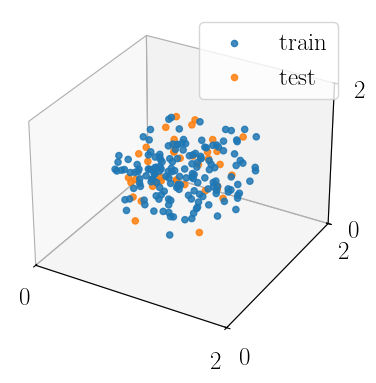

In [8]:
# Scatter plot of train/test parameter distribution
fig = plt.figure(figsize=(5,4))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(params_train[:,0], params_train[:,1], params_train[:,2], c="tab:blue", s=20, alpha=0.85, label="train")
ax.scatter(params_test[:,0],  params_test[:,1],  params_test[:,2],  c="tab:orange", s=20, alpha=0.85, label="test")
ax.set_xticks([0, 2]); ax.set_yticks([0, 2]); ax.set_zticks([0, 2])
ax.set_xlim(0, 2); ax.set_ylim(0, 2); ax.set_zlim(0, 2)
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
# Load monolithic SVD bases for E and B
data = np.load(os.path.join(savedir,"E_svd_rank120_Mortho.npz"))
U_mono_E, S_mono_E, Vt = data["U"], data["S"], data["Vt"]
print("Check for M-orthonormality: ||U^T M U - I|| = ", np.linalg.norm(U_mono_E.T @ M_E @ U_mono_E - np.eye(U_mono_E.shape[1])))

data = np.load(os.path.join(savedir,"B_svd_rank120_Mortho.npz"))
U_mono_B, S_mono_B, Vt = data["U"], data["S"], data["Vt"]
print("Check for orthonormality: ||U^T U - I|| = ", np.linalg.norm(U_mono_B.T @ M_B @ U_mono_B - np.eye(U_mono_B.shape[1])))

Check for M-orthonormality: ||U^T M U - I|| =  1.011550049219758e-13
Check for orthonormality: ||U^T U - I|| =  8.362105440140618e-14


In [10]:
# Load Tucker decompositions for E and B
core_E, factors_E = load_tucker_npz(os.path.join(savedir, "tucker_E_150x120x150_Mortho.npz"))
tucker_tensor_E = TuckerTensor((core_E, factors_E))
print("E: ", tucker_tensor_E.shape)

core_B, factors_B = load_tucker_npz(os.path.join(savedir, "tucker_B_150x120x150_Mortho.npz"))
tucker_tensor_B = TuckerTensor((core_B, factors_B))
print("B: ", tucker_tensor_B.shape)

E:  (49320, 121, 160)
B:  (82350, 121, 160)


# Single parameter predictions

In [11]:
# ROM rank values to sweep
r_arr = [1, 5, 10, 20, 40, 80, 120]
r_arr = np.asarray(r_arr, dtype=int)

In [12]:
# Select a single test parameter and set source
idx = 2
r_idx_rbf = 2
r_idx_mo = 2
r_idx_mono = 2

mid = params_test[idx,:3]
width = 0.1
dir = np.array([1,1,1])

sim.set_source(mid, width, dir)

In [13]:
# Save FOM solution snapshots as PNGs
requested = [2.5] 
clims = save_pngs(
    sim.mesh, file_hdf5, os.path.join(savedir, "sim"),
    recorded_times=times,
    requested_times=requested,
    E_arr=snapshots_E_test[...,idx],
    B_arr=snapshots_B_test[...,idx],
    image_size=(1000, 350),
    renderer='matplotlib',
    return_clims=True,
)

  ==> saving PNG snapshots: 100%|██████████| 1/1 [00:02<00:00,  2.57s/it]


In [14]:
# Initialize Radial Basis Function interpolants for E and B
rbfw_E = RBFWeights(
        mus=params_train,
        basis="gaussian", 
        eps=1.8,
        order=-1,       
        nugget=0
)

rbfw_B = RBFWeights(
        mus=params_train,
        basis="gaussian", 
        eps=1.8,
        order=-1,       
        nugget=0
)

In [15]:
# Build RBF basis for E, compute projection error
W_rbf_E     = rbfw_E.weights(params_test[idx])
U_rbf_E, s_rbf_E, _ = buildParBasis(tucker_tensor_E, W_rbf_E)

print(projection_error_M(snapshots_E_test[...,idx], U_rbf_E[:,:r_arr[r_idx_rbf]], M_E, Mnorm))
np.linalg.norm(U_rbf_E.T @ M_E @ U_rbf_E - np.eye(U_rbf_E.shape[1]))


0.004926279693409642


np.float64(8.574631853097804e-14)

In [16]:
# Build RBF basis for B, compute projection error
W_rbf_B     = rbfw_B.weights(params_test[idx])
U_rbf_B, s_rbf_B, _ = buildParBasis(tucker_tensor_B, W_rbf_B)
print(projection_error_M(snapshots_B_test[...,idx], U_rbf_B[:,:r_arr[r_idx_rbf]], M_B, Mnorm))
np.linalg.norm(U_rbf_B.T @ M_B @ U_rbf_B - np.eye(U_rbf_B.shape[1]))


0.0021766646856403284


np.float64(8.957427690727525e-14)

In [17]:
# Enrich RBF bases with curl modes, solve hyper ROM, compute errors
r = r_arr[r_idx_rbf]
# Enriched E basis: U_E + weak curl of U_B
U_E_aug = np.hstack([U_rbf_E[:, :r], Wk @ U_rbf_B[:, :r]])
U_E_orth = m_orthonormalize_chol(U_E_aug, M_E)

# Enriched B basis: U_B + strong curl of U_E
U_B_aug = np.hstack([U_rbf_B[:, :r], St @ U_rbf_E[:, :r]])
U_B_orth = m_orthonormalize_chol(U_B_aug, M_B)


r_use = min(U_E_orth.shape[1], U_B_orth.shape[1])
ROM = MaxwellHyperROM(sim, U_E_orth[:, :r_use], U_B_orth[:, :r_use], **hyper_kwargs)
(E_rbf, B_rbf), t = ROM.timeLoop(0, 2.5, 120)

E_recon = U_E_orth[:, :r_use] @ E_rbf
B_recon = U_B_orth[:, :r_use] @ B_rbf

err_E = Mnorm(snapshots_E_test[..., idx] - E_recon, M_E) / Mnorm(snapshots_E_test[..., idx], M_E)
err_B = Mnorm(snapshots_B_test[..., idx] - B_recon, M_B) / Mnorm(snapshots_B_test[..., idx], M_B)

print(f"Relative error in E: {err_E:.4e}")
print(f"Relative error in B: {err_B:.4e}")

requested = [2.5] 
save_pngs(
    sim.mesh, file_hdf5, os.path.join(savedir, "rbf"),
    recorded_times=times,
    requested_times=requested,
    E_arr=E_recon,
    B_arr=B_recon,
    image_size=(1000, 350),
    renderer='matplotlib',
    reference_clims=clims,
    show_colorbar=False
)

Relative error in E: 8.7734e-03
Relative error in B: 3.1006e-02


  ==> saving PNG snapshots: 100%|██████████| 1/1 [00:00<00:00,  3.27it/s]


In [18]:
# Enrich monolithic bases with curl modes, solve hyper ROM, compute errors
r = r_arr[r_idx_mono]
# Enriched E basis: U_E + weak curl of U_B
U_E_aug = np.hstack([U_mono_E[:, :r], Wk @ U_mono_B[:, :r]])
U_E_orth = m_orthonormalize_chol(U_E_aug, M_E)

# Enriched B basis: U_B + strong curl of U_E
U_B_aug = np.hstack([U_mono_B[:, :r], St @ U_mono_E[:, :r]])
U_B_orth = m_orthonormalize_chol(U_B_aug, M_B)


r_use = min(U_E_orth.shape[1], U_B_orth.shape[1])
ROM = MaxwellHyperROM(sim, U_E_orth[:, :r_use], U_B_orth[:, :r_use], **hyper_kwargs)
(E_mono, B_mono), t = ROM.timeLoop(0, 2.5, 120)

E_recon = U_E_orth[:, :r_use] @ E_mono
B_recon = U_B_orth[:, :r_use] @ B_mono

err_E = Mnorm(snapshots_E_test[..., idx] - E_recon, M_E) / Mnorm(snapshots_E_test[..., idx], M_E)
err_B = Mnorm(snapshots_B_test[..., idx] - B_recon, M_B) / Mnorm(snapshots_B_test[..., idx], M_B)

print(f"Relative error in E: {err_E:.4e}")
print(f"Relative error in B: {err_B:.4e}")

requested = [2.5] 
save_pngs(
    sim.mesh, file_hdf5, os.path.join(savedir, "mono"),
    recorded_times=times,
    requested_times=requested,
    E_arr=E_recon,
    B_arr=B_recon,
    image_size=(1000, 350),
    renderer='matplotlib',
    reference_clims=clims, 
    show_colorbar=False
)

Relative error in E: 3.6870e-01
Relative error in B: 4.4415e-01


  ==> saving PNG snapshots: 100%|██████████| 1/1 [00:00<00:00,  3.44it/s]


In [19]:
# Enrich MO bases with curl modes, solve hyper ROM, compute errors
W_mo = mo(params_train, 15, params_test[idx], eps=1e-16, rcond=1e-16)
U_mo_E, _, _ = buildParBasis(tucker_tensor_E, W_mo)
U_mo_B, _, _ = buildParBasis(tucker_tensor_B, W_mo)

r = r_arr[r_idx_mo]
# Enriched E basis: U_E + weak curl of U_B
U_E_aug = np.hstack([U_mo_E[:, :r], Wk @ U_mo_B[:, :r]])
U_E_orth = m_orthonormalize_chol(U_E_aug, M_E)

# Enriched B basis: U_B + strong curl of U_E
U_B_aug = np.hstack([U_mo_B[:, :r], St @ U_mo_E[:, :r]])
U_B_orth = m_orthonormalize_chol(U_B_aug, M_B)


r_use = min(U_E_orth.shape[1], U_B_orth.shape[1])
ROM = MaxwellHyperROM(sim, U_E_orth[:, :r_use], U_B_orth[:, :r_use], **hyper_kwargs)
(E_mo, B_mo), t = ROM.timeLoop(0, 2.5, 120)

E_recon = U_E_orth[:, :r_use] @ E_mo
B_recon = U_B_orth[:, :r_use] @ B_mo

err_E = Mnorm(snapshots_E_test[..., idx] - E_recon, M_E) / Mnorm(snapshots_E_test[..., idx], M_E)
err_B = Mnorm(snapshots_B_test[..., idx] - B_recon, M_B) / Mnorm(snapshots_B_test[..., idx], M_B)

print(f"Relative error in E: {err_E:.4e}")
print(f"Relative error in B: {err_B:.4e}")

requested = [2.5] 
save_pngs(
    sim.mesh, file_hdf5, os.path.join(savedir, "mo"),
    recorded_times=times,
    requested_times=requested,
    E_arr=E_recon,
    B_arr=B_recon,
    image_size=(1000, 350),
    renderer='matplotlib',
    reference_clims=clims,
    show_colorbar=False
)

Relative error in E: 4.1972e-02
Relative error in B: 3.8236e-02


  ==> saving PNG snapshots: 100%|██████████| 1/1 [00:00<00:00,  2.67it/s]


# Parameter sweep

In [ ]:
# Instantiate basis builders for each method
mono_builder = build_mono_bases(U_mono_E, U_mono_B)
rbf_builder  = build_rbf_bases(rbfw_E, rbfw_B, tucker_tensor_E, tucker_tensor_B, buildParBasis)
mo_builder  = build_mo_bases(params_train, mo, tucker_tensor_E, tucker_tensor_B, buildParBasis,
                               k=15, eps=1e-14, rcond=1e-14)


In [ ]:
# Wrap basis builders with curl enrichment
mono_builder_enriched = enrich_builder(mono_builder, Wk, St, M_E, M_B)
rbf_builder_enriched  = enrich_builder(rbf_builder,  Wk, St, M_E, M_B)
mo_builder_enriched  = enrich_builder(mo_builder,   Wk, St, M_E, M_B)


In [20]:
# Fix source width and direction for the parameter sweep
width = 0.1
dir = [1,1,1]

In [ ]:
# Sweep errors over the test set
mono_romE_te, mono_romB_te, mono_projE_te, mono_projB_te = sweep_dataset(
    sim, None, params_test, r_arr,
    snapshots_E_test, snapshots_B_test,
    width, dir, M_E, M_B, Mnorm, mono_builder_enriched, label="mono test", enriched=True,
    hyper=True, qdeim_data=hyper_kwargs
)

rbf_romE_te, rbf_romB_te, rbf_projE_te, rbf_projB_te = sweep_dataset(
    sim, None, params_test, r_arr,
    snapshots_E_test, snapshots_B_test,
    width, dir, M_E, M_B, Mnorm, rbf_builder_enriched, label="rbf test", enriched=True,
    hyper=True, qdeim_data=hyper_kwargs
)

mo_romE_te, mo_romB_te, mo_projE_te, mo_projB_te = sweep_dataset(
    sim, None, params_test, r_arr,
    snapshots_E_test, snapshots_B_test,
    width, dir, M_E, M_B, Mnorm, mo_builder_enriched, label="mo test", enriched=True,
    hyper=True, qdeim_data=hyper_kwargs
)

mono test: 40/40
rbf test: 40/40
lid test: 40/40


In [ ]:
# Sweep errors over the training set
mono_romE_tr, mono_romB_tr, mono_projE_tr, mono_projB_tr = sweep_dataset(
    sim, None, params_train, r_arr,
    snapshots_E_train, snapshots_B_train,
    width, dir, M_E, M_B, Mnorm, mono_builder_enriched, label="mono train", enriched=True,
    hyper=True, qdeim_data=hyper_kwargs
)

rbf_romE_tr, rbf_romB_tr, rbf_projE_tr, rbf_projB_tr = sweep_dataset(
    sim, None, params_train, r_arr,
    snapshots_E_train, snapshots_B_train,
    width, dir, M_E, M_B, Mnorm, rbf_builder_enriched, label="rbf train", enriched=True,
    hyper=True, qdeim_data=hyper_kwargs
)

mo_romE_tr, mo_romB_tr, mo_projE_tr, mo_projB_tr = sweep_dataset(
    sim, None, params_train, r_arr,
    snapshots_E_train, snapshots_B_train,
    width, dir, M_E, M_B, Mnorm, mo_builder_enriched, label="mo train", enriched=True,
    hyper=True, qdeim_data=hyper_kwargs
)


mono train: 160/160
rbf train: 160/160
lid train: 160/160


### Save

In [ ]:
# Save all sweep results to disk
np.savez(
    os.path.join(savedir, "errors_B_M_ortho_enriched_hyper.npz"),
    r_arr=r_arr,
    params_train=params_train,
    params_test=params_test,

    mono_romE_train=mono_romE_tr, mono_romB_train=mono_romB_tr,
    mono_projE_train=mono_projE_tr, mono_projB_train=mono_projB_tr,
    mono_romE_test=mono_romE_te,  mono_romB_test=mono_romB_te,
    mono_projE_test=mono_projE_te, mono_projB_test=mono_projB_te,

    rbf_romE_train=rbf_romE_tr, rbf_romB_train=rbf_romB_tr,
    rbf_projE_train=rbf_projE_tr, rbf_projB_train=rbf_projB_tr,
    rbf_romE_test=rbf_romE_te,  rbf_romB_test=rbf_romB_te,
    rbf_projE_test=rbf_projE_te, rbf_projB_test=rbf_projB_te,

    mo_romE_train=mo_romE_tr, mo_romB_train=mo_romB_tr,
    mo_projE_train=mo_projE_tr, mo_projB_train=mo_projB_tr,
    mo_romE_test=mo_romE_te,  mo_romB_test=mo_romB_te,
    mo_projE_test=mo_projE_te, mo_projB_test=mo_projB_te,
)

/Users/arjunveejay/Documents/Code/Private repos/TuckerROMs/src/Maxwell/plots.py:447: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(bottom=0.16)


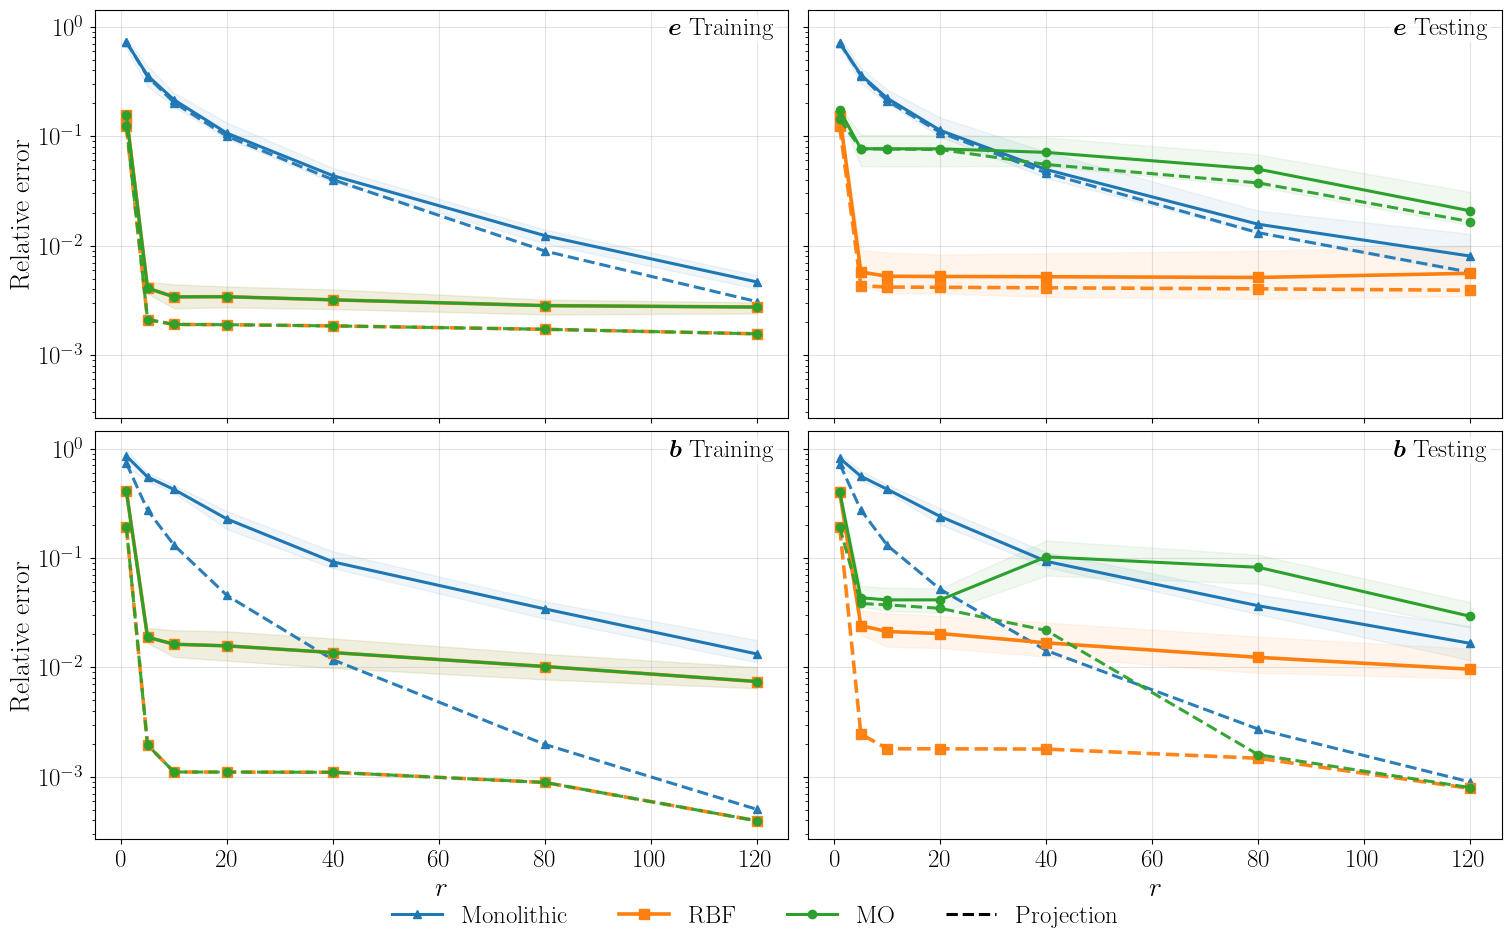

In [4]:
# Load and plot ROM and projection error curves
errs = np.load(os.path.join(savedir, "errors_B_M_ortho_enriched_hyper.npz"))
plot_errors(errs)
plt.savefig("errors_maxwell.pdf", bbox_inches='tight')
plt.show()
